# TP1 – Continual Learning on Seq-CIFAR-10

**I309 – Visión Artificial Avanzada – Universidad de San Andrés**

This notebook covers the full pipeline:
1. **Configuration** – all hyperparameters in one place
2. **Backbone pre-training** with Supervised Contrastive Loss (SupCon)
3. **Four CL methods**: Fine-Tune, EWC, LwF, Co²L
4. **Comparison**: unified table + accuracy and forgetting curves

> Run cells top-to-bottom. Skip *Section 2* if `backbone.pth` already exists.  
> Skip *Section 3* if `graphs/results.json` already exists (use `--skip-training` logic in the load cell).

---
## 0 · Imports & device

In [1]:
import os, json, copy
import numpy as np
# !pip install torch torchvision matplotlib
# !pip install scikit-learn
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── project modules ───────────────────────────────────────────────────────────
from data.prepare_cifar10 import task_splits, TASKS, CIFAR10_CLASSES
from models.train_backbone import (
    BackboneModel, build_backbone, train_backbone,
    EMBEDDING_DIM, TEMPERATURE,
)
from models.finetune import train_finetune
from models.ewc      import train_ewc
from models.lwf      import train_lwf
from models.co2l     import train_co2l

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")


PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version PyTorch was built with: 12.8


---
## 1 · Configuration

Change any value here — the rest of the notebook picks it up automatically.

In [3]:
# ── Backbone pre-training ─────────────────────────────────────────────────────
BACKBONE_EPOCHS  = 50       # epochs for SupCon pre-training (task 0 only)
BACKBONE_LR      = 5e-3
BACKBONE_TEMP    = 0.07     # SupCon temperature τ
BACKBONE_WEIGHTS = 'backbone.pth'

# ── Common CL hyperparameters ─────────────────────────────────────────────────
CL_EPOCHS     = 10          # backbone/joint-head training epochs per task
CL_LR         = 1e-3
BATCH_SIZE    = 64
HEAD_EPOCHS   = 10          # Task-IL head training epochs (frozen backbone)
HEAD_LR       = 8e-4

# ── Method-specific ───────────────────────────────────────────────────────────
LAMBDA_EWC    = 5000.0      # EWC regularisation strength
FISHER_SAMPLES = 500        # samples used to estimate Fisher diagonal

LAMBDA_LWF    = 1.0         # LwF distillation weight
TEMPERATURE_LWF = 2.0       # soft-target temperature

LAMBDA_CO2L   = 1.0         # Co²L distillation weight
BUFFER_SIZE   = 200         # replay buffer capacity (total across all tasks)

# ── Output ────────────────────────────────────────────────────────────────────
GRAPHS_DIR   = 'graphs'
RESULTS_PATH = os.path.join(GRAPHS_DIR, 'results.json')
os.makedirs(GRAPHS_DIR, exist_ok=True)

# ── Which methods to run ──────────────────────────────────────────────────────
# Set to False to skip a method (results still loaded from cache if available)
RUN_FINETUNE = True
RUN_EWC      = True
RUN_LWF      = True
RUN_CO2L     = True

print('Configuration loaded ✓')

Configuration loaded ✓


---
## 1.5 · Dataset overview

In [4]:
print('Seq-CIFAR-10 split:')
print(f'{"Task":<6} {"Classes":<30} {"Train":>7} {"Test":>7}')
print('-' * 55)
for i, (split, cls) in enumerate(zip(task_splits, TASKS)):
    names = ', '.join(CIFAR10_CLASSES[c] for c in cls)
    print(f'{i:<6} {names:<30} {len(split["train"]):>7} {len(split["test"]):>7}')

Seq-CIFAR-10 split:
Task   Classes                          Train    Test
-------------------------------------------------------
0      airplane, automobile             10000    2000
1      bird, cat                        10000    2000
2      deer, dog                        10000    2000
3      frog, horse                      10000    2000
4      ship, truck                      10000    2000


---
## 2 · Backbone pre-training (Etapa 4.2)

Trains a ResNet-18 backbone on **Task 0** with Supervised Contrastive Loss and saves `backbone.pth`.  
**Skip this cell if `backbone.pth` already exists.**

In [5]:
if os.path.exists(BACKBONE_WEIGHTS):
    print(f'Found {BACKBONE_WEIGHTS} — skipping training.')
else:
    print(f'Training backbone for {BACKBONE_EPOCHS} epochs on Task 0 …')
    train_backbone(
        task_number=0,
        num_epochs=BACKBONE_EPOCHS,
        lr=BACKBONE_LR,
        temperature=BACKBONE_TEMP,
        batch_size=BATCH_SIZE,
        save_path=BACKBONE_WEIGHTS,
    )
    print('Backbone saved ✓')

Training backbone for 50 epochs on Task 0 …
Snapshot collected: epoch 0 (before training)
  Epoch [1/50]  Loss: 4.0293
  Epoch [2/50]  Loss: 3.9136
  Epoch [3/50]  Loss: 3.8290
  Epoch [4/50]  Loss: 3.7961
  Epoch [5/50]  Loss: 3.7486
  Epoch [6/50]  Loss: 3.7092
  Epoch [7/50]  Loss: 3.6666
  Epoch [8/50]  Loss: 3.6323
  Epoch [9/50]  Loss: 3.6178
  Epoch [10/50]  Loss: 3.5990
  Epoch [11/50]  Loss: 3.5826
  Epoch [12/50]  Loss: 3.5704
  Epoch [13/50]  Loss: 3.5630
  Epoch [14/50]  Loss: 3.5506
  Epoch [15/50]  Loss: 3.5551
  Epoch [16/50]  Loss: 3.5454
  Epoch [17/50]  Loss: 3.5490
  Epoch [18/50]  Loss: 3.5380
  Epoch [19/50]  Loss: 3.5333
  Epoch [20/50]  Loss: 3.5346
  Epoch [21/50]  Loss: 3.5212
  Epoch [22/50]  Loss: 3.5155
  Epoch [23/50]  Loss: 3.5205
  Epoch [24/50]  Loss: 3.5050
  Epoch [25/50]  Loss: 3.5068
Snapshot collected: epoch 25 (mid-training)
  Epoch [26/50]  Loss: 3.5034
  Epoch [27/50]  Loss: 3.5061
  Epoch [28/50]  Loss: 3.5078
  Epoch [29/50]  Loss: 3.5101
  Epo

### 2.1 · t-SNE embedding visualisation

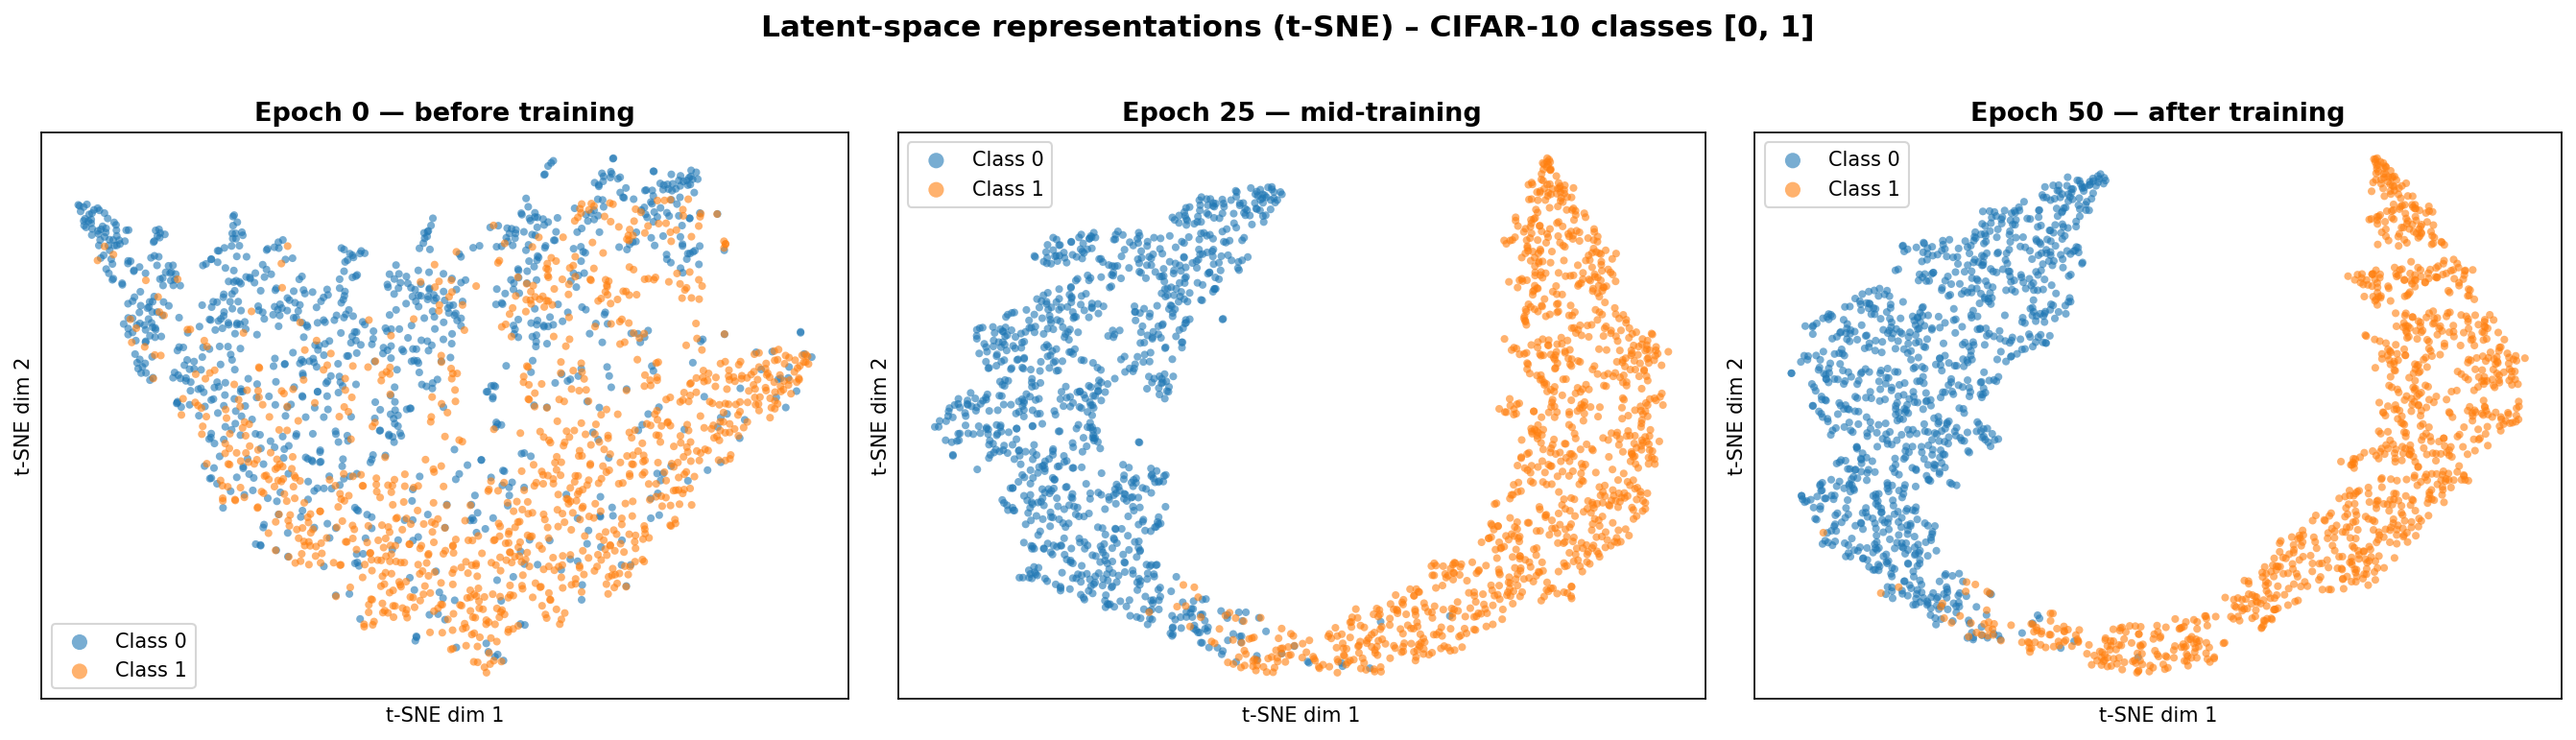

In [6]:
snap_path = os.path.join(GRAPHS_DIR, 'latent_space_snapshots.png')
if os.path.exists(snap_path):
    from IPython.display import Image, display
    display(Image(snap_path))
else:
    print('Run backbone training first to generate snapshots.')

---
## 3 · Continual Learning methods (Etapa 4.3)

Each method trains sequentially over all 5 tasks and records Class-IL and Task-IL accuracy after each task.  
Results are cached in `graphs/results.json` — re-run only the methods you change.

In [7]:
# Load existing results (if any) so we don't re-run completed methods
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        results = json.load(f)
    print(f'Loaded cached results for: {list(results.keys())}')
else:
    results = {}
    print('No cached results — will run all selected methods.')

def _save_results():
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved → {RESULTS_PATH}')

Loaded cached results for: ['Fine-Tune', 'EWC', 'LwF', 'Co2L']


### 3.1 · Fine-Tune (naive baseline)

In [8]:
if RUN_FINETUNE:
    print('Running Fine-Tune …')
    results['Fine-Tune'] = train_finetune(
        backbone_weights=BACKBONE_WEIGHTS,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('Fine-Tune skipped (RUN_FINETUNE=False)')

Running Fine-Tune …

Fine-Tune  |  Task 1 / 5
  Epoch [1/10]  Loss: 0.0159
  Epoch [2/10]  Loss: 0.0036
  Epoch [3/10]  Loss: 0.0028
  Epoch [4/10]  Loss: 0.0024
  Epoch [5/10]  Loss: 0.0059
  Epoch [6/10]  Loss: 0.0037
  Epoch [7/10]  Loss: 0.0010
  Epoch [8/10]  Loss: 0.0035
  Epoch [9/10]  Loss: 0.0021
  Epoch [10/10]  Loss: 0.0012
  Training Task-IL head for task 1…
  >> Class-IL: 99.05%  |  Task-IL: 98.60%

Fine-Tune  |  Task 2 / 5
  Epoch [1/10]  Loss: 0.9314
  Epoch [2/10]  Loss: 0.4954
  Epoch [3/10]  Loss: 0.4038
  Epoch [4/10]  Loss: 0.3621
  Epoch [5/10]  Loss: 0.3301
  Epoch [6/10]  Loss: 0.3097
  Epoch [7/10]  Loss: 0.2832
  Epoch [8/10]  Loss: 0.2740
  Epoch [9/10]  Loss: 0.2603
  Epoch [10/10]  Loss: 0.2372
  Training Task-IL head for task 2…
  >> Class-IL: 44.02%  |  Task-IL: 89.00%

Fine-Tune  |  Task 3 / 5
  Epoch [1/10]  Loss: 0.7284
  Epoch [2/10]  Loss: 0.2674
  Epoch [3/10]  Loss: 0.2357
  Epoch [4/10]  Loss: 0.2104
  Epoch [5/10]  Loss: 0.1906
  Epoch [6/10]  Los

### 3.2 · Elastic Weight Consolidation (EWC)

In [9]:
if RUN_EWC:
    print('Running EWC …')
    results['EWC'] = train_ewc(
        backbone_weights=BACKBONE_WEIGHTS,
        lambda_ewc=LAMBDA_EWC, fisher_samples=FISHER_SAMPLES,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('EWC skipped (RUN_EWC=False)')

Running EWC …

EWC  |  Task 1 / 5
  Epoch [1/10]  Loss: 0.0173
  Epoch [2/10]  Loss: 0.0051
  Epoch [3/10]  Loss: 0.0042
  Epoch [4/10]  Loss: 0.0050
  Epoch [5/10]  Loss: 0.0010
  Epoch [6/10]  Loss: 0.0024
  Epoch [7/10]  Loss: 0.0040
  Epoch [8/10]  Loss: 0.0017
  Epoch [9/10]  Loss: 0.0023
  Epoch [10/10]  Loss: 0.0025
  Computing Fisher Information Matrix…
  >> Class-IL: 98.80%  |  Task-IL: 98.60%

EWC  |  Task 2 / 5
  Epoch [1/10]  Loss: 0.9154
  Epoch [2/10]  Loss: 0.4914
  Epoch [3/10]  Loss: 0.3979
  Epoch [4/10]  Loss: 0.3568
  Epoch [5/10]  Loss: 0.3232
  Epoch [6/10]  Loss: 0.3054
  Epoch [7/10]  Loss: 0.2891
  Epoch [8/10]  Loss: 0.2719
  Epoch [9/10]  Loss: 0.2580
  Epoch [10/10]  Loss: 0.2397
  Computing Fisher Information Matrix…
  >> Class-IL: 44.15%  |  Task-IL: 87.97%

EWC  |  Task 3 / 5
  Epoch [1/10]  Loss: 0.7378
  Epoch [2/10]  Loss: 0.2622
  Epoch [3/10]  Loss: 0.2376
  Epoch [4/10]  Loss: 0.2133
  Epoch [5/10]  Loss: 0.2010
  Epoch [6/10]  Loss: 0.1886
  Epoch 

### 3.3 · Learning without Forgetting (LwF)

In [10]:
if RUN_LWF:
    print('Running LwF …')
    results['LwF'] = train_lwf(
        backbone_weights=BACKBONE_WEIGHTS,
        lambda_lwf=LAMBDA_LWF, temperature=TEMPERATURE_LWF,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('LwF skipped (RUN_LWF=False)')

Running LwF …

LwF  |  Task 1 / 5
  Epoch [1/10]  Loss: 0.0226
  Epoch [2/10]  Loss: 0.0060
  Epoch [3/10]  Loss: 0.0064
  Epoch [4/10]  Loss: 0.0051
  Epoch [5/10]  Loss: 0.0028
  Epoch [6/10]  Loss: 0.0034
  Epoch [7/10]  Loss: 0.0018
  Epoch [8/10]  Loss: 0.0031
  Epoch [9/10]  Loss: 0.0030
  Epoch [10/10]  Loss: 0.0013
  >> Class-IL: 98.80%  |  Task-IL: 98.80%

LwF  |  Task 2 / 5
  Epoch [1/10]  Loss: 1.0115
  Epoch [2/10]  Loss: 0.5615
  Epoch [3/10]  Loss: 0.4693
  Epoch [4/10]  Loss: 0.4119
  Epoch [5/10]  Loss: 0.3800
  Epoch [6/10]  Loss: 0.3528
  Epoch [7/10]  Loss: 0.3358
  Epoch [8/10]  Loss: 0.3208
  Epoch [9/10]  Loss: 0.3027
  Epoch [10/10]  Loss: 0.2838
  >> Class-IL: 44.08%  |  Task-IL: 89.95%

LwF  |  Task 3 / 5
  Epoch [1/10]  Loss: 0.8254
  Epoch [2/10]  Loss: 0.2943
  Epoch [3/10]  Loss: 0.2628
  Epoch [4/10]  Loss: 0.2447
  Epoch [5/10]  Loss: 0.2277
  Epoch [6/10]  Loss: 0.2176
  Epoch [7/10]  Loss: 0.2082
  Epoch [8/10]  Loss: 0.1968
  Epoch [9/10]  Loss: 0.1866

### 3.4 · Contrastive Continual Learning (Co²L)

In [11]:
if RUN_CO2L:
    print('Running Co²L …')
    results['Co2L'] = train_co2l(
        backbone_weights=BACKBONE_WEIGHTS,
        lambda_co2l=LAMBDA_CO2L, temperature=TEMPERATURE,
        buffer_size=BUFFER_SIZE,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('Co²L skipped (RUN_CO2L=False)')

Running Co²L …

Co2L  |  Task 1 / 5
  Epoch [1/10]  Loss: 3.4591  SupCon: 3.4591  Distill: 0.0000
  Epoch [2/10]  Loss: 3.4490  SupCon: 3.4490  Distill: 0.0000
  Epoch [3/10]  Loss: 3.4396  SupCon: 3.4396  Distill: 0.0000
  Epoch [4/10]  Loss: 3.4418  SupCon: 3.4418  Distill: 0.0000
  Epoch [5/10]  Loss: 3.4397  SupCon: 3.4397  Distill: 0.0000
  Epoch [6/10]  Loss: 3.4462  SupCon: 3.4462  Distill: 0.0000
  Epoch [7/10]  Loss: 3.4397  SupCon: 3.4397  Distill: 0.0000
  Epoch [8/10]  Loss: 3.4441  SupCon: 3.4441  Distill: 0.0000
  Epoch [9/10]  Loss: 3.4405  SupCon: 3.4405  Distill: 0.0000
  Epoch [10/10]  Loss: 3.4387  SupCon: 3.4387  Distill: 0.0000
  Updating replay buffer (capacity=200)…
  ReplayBuffer(capacity=200, stored=200, seen=10000)
  Training Class-IL joint head…
  >> Class-IL: 98.55%  |  Task-IL: 98.50%

Co2L  |  Task 2 / 5
  Epoch [1/10]  Loss: 3.2844  SupCon: 4.2803  Distill: -0.9959
  Epoch [2/10]  Loss: 3.2510  SupCon: 4.2497  Distill: -0.9987
  Epoch [3/10]  Loss: 2.9116

AcceleratorError: CUDA error: unspecified launch failure
Search for `cudaErrorLaunchFailure' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


---
## 4 · Comparison of results (Etapa 4.4)

### 4.1 · Unified results table

In [12]:
METHODS = ['Fine-Tune', 'EWC', 'LwF', 'Co2L']
COLORS  = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']
TASK_LABELS = [f'T{i}' for i in range(1, 6)]

col_w = 12
header = f'{"Method":<{col_w}}' + ''.join(
    f'  {"T"+str(t)+" CIL":>8}  {"T"+str(t)+" TIL":>8}' for t in range(1, 6)
)
sep = '=' * len(header)
print(sep)
print('RESULTS — Class-IL (CIL) and Task-IL (TIL) accuracy (%) after each task')
print(sep)
print(header)
print('-' * len(header))
for method in METHODS:
    if method not in results:
        continue
    r = results[method]
    row = f'{method:<{col_w}}'
    for i in range(5):
        row += f'  {r["class_il"][i]:>8.2f}  {r["task_il"][i]:>8.2f}'
    print(row)
print(sep)

RESULTS — Class-IL (CIL) and Task-IL (TIL) accuracy (%) after each task
Method          T1 CIL    T1 TIL    T2 CIL    T2 TIL    T3 CIL    T3 TIL    T4 CIL    T4 TIL    T5 CIL    T5 TIL
----------------------------------------------------------------------------------------------------------------
Fine-Tune        99.05     98.60     44.02     89.00     31.05     80.82     24.40     75.62     19.24     76.27
EWC              98.80     98.60     44.15     87.97     31.30     84.08     24.36     75.39     19.35     75.83
LwF              98.80     98.80     44.08     89.95     31.15     91.53     24.32     87.53     19.35     84.95
Co2L             98.30     98.30     62.02     85.45     46.77     79.47     34.90     80.17     21.12     80.26


### 4.2 · Accuracy curves

In [13]:
tasks = list(range(1, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Continual Learning on Seq-CIFAR-10', fontsize=14, fontweight='bold')

for method, color in zip(METHODS, COLORS):
    if method not in results:
        continue
    r = results[method]
    ax1.plot(tasks, r['class_il'], marker='o', label=method, color=color, linewidth=2)
    ax2.plot(tasks, r['task_il'],  marker='o', label=method, color=color, linewidth=2)

for ax, title in [
    (ax1, 'Class-Incremental Learning (Class-IL)'),
    (ax2, 'Task-Incremental Learning (Task-IL)'),
]:
    ax.set_xlabel('Tasks Learned', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(tasks)
    ax.set_xticklabels(TASK_LABELS)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(GRAPHS_DIR, 'accuracy_curves.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

Saved → graphs/accuracy_curves.png


/tmp/ipykernel_150823/4059640810.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 4.3 · Forgetting curves

Class-IL accuracy over tasks acts as a forgetting proxy: a steeper drop means more catastrophic forgetting.

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(
    'Forgetting — Class-IL Accuracy Over Tasks\n'
    '(steeper drop = more catastrophic forgetting)',
    fontsize=12,
)
for method, color in zip(METHODS, COLORS):
    if method not in results:
        continue
    r = results[method]
    ax.plot(tasks, r['class_il'], marker='o', label=method, color=color, linewidth=2)

ax.set_xlabel('Tasks Learned', fontsize=11)
ax.set_ylabel('Class-IL Accuracy (%)', fontsize=11)
ax.set_xticks(tasks)
ax.set_xticklabels(TASK_LABELS)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(GRAPHS_DIR, 'forgetting_curves.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

Saved → graphs/forgetting_curves.png


/tmp/ipykernel_150823/960760234.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 4.4 · Final accuracy summary (after all 5 tasks)

In [ ]:
print(f'{"Method":<12}  {"Final Class-IL":>15}  {"Final Task-IL":>14}')
print('-' * 46)
for method in METHODS:
    if method not in results:
        continue
    r = results[method]
    print(f'{method:<12}  {r["class_il"][-1]:>14.2f}%  {r["task_il"][-1]:>13.2f}%')

print('\nPaper targets (Co²L on Seq-CIFAR-10):')
print('  Class-IL ≈ 47–52%   Task-IL ≈ 88–92%')